In [1]:
import json
import os
import sys
with open("client_ip.json", "r") as f:
    client_ip = json.load(f)

In [2]:
batch_size = 128
features = 40
input_shape = (features,1)

In [3]:
import matplotlib.pyplot as plt
import numpy as np
WINDOW=256
def lstm_vector(ts1, sizes1, ts2, sizes2, voip=False, window=256):
    # 1) determine src/dst order
    if voip or ts1[0] < ts2[0]:
        src_ts, src_sizes, dst_ts, dst_sizes = ts1, sizes1, ts2, sizes2
    else:
        src_ts, src_sizes, dst_ts, dst_sizes = ts2, sizes2, ts1, sizes1

    sizes = []
    j = k = 0
    min_val = min(src_ts[0], dst_ts[0])

    # 2) merge until we have `window` events or exhaust both streams
    while len(sizes) < window:
        if j >= len(src_ts) and k >= len(dst_ts):
            break
        if j >= len(src_ts):
            sizes.append(dst_sizes[k])
            k += 1
        elif k >= len(dst_ts):
            sizes.append(src_sizes[j])
            j += 1
        elif src_ts[j] <= dst_ts[k]:
            sizes.append(src_sizes[j])
            j += 1
        else:
            sizes.append(dst_sizes[k])
            k += 1

    # 3) pad with zeros up to `window`
    if len(sizes) < window:
        sizes.extend([0] * (window - len(sizes)))

    # 4) return as (window, 1)
    return np.array(sizes, dtype=float).reshape(window, 1)

In [4]:
def check_strings_in_classname(classname):
    keywords = {
    "web": 0, "video": 1, "social": 2, "email": 3,"voip":4,"chat":5,"gaming":6,"docs":7
    }
    for keyword in keywords:
        if keyword in classname:
            return keywords[keyword] 
    return None

In [5]:
# from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from keras.callbacks import TensorBoard, ModelCheckpoint
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout,LSTM,BatchNormalization
from keras import backend as K
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from keras.metrics import top_k_categorical_accuracy
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow.keras.backend as K

def precision(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    return precision

def recall(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    recall = true_positives / (possible_positives + K.epsilon())
    return recall
def f1_score(y_true, y_pred):
    prec = precision(y_true, y_pred)
    rec = recall(y_true, y_pred)
    return 2 * ((prec * rec) / (prec + rec))

In [6]:
X_train = []
y_train = []
voip = []
gaming = []
web = []
video = []
social = []
email = []
doc = []
microsoft = []
chat = []
background = []

In [7]:
path2 = os.path.abspath('..')
import os
import csv
import tensorflow as tf

folder_path = path2+"/labeled_train"


In [8]:
import json
def traffic_csv_converter(file_path):
    X_train = []
    y_train = []
    with open(file_path, 'r') as csv_file:
        reader = csv.reader(csv_file)
        filename = os.path.splitext(os.path.basename(file_path))[0]
        flow_val = {}
        class_val = {}
        paired_keys = set()
        for i, row in enumerate(reader):
            class_name = row[0]
            src_ip = row[1]
            src_port = row[2]
            dst_ip = row[3]
            dst_port = row[4]
            length = int(row[7])
            ts = np.array(row[8:8+length], dtype=float)
            sizes = np.array(row[9+length:], dtype=int)
            key = (src_ip, src_port, dst_ip, dst_port)
            reverse_key = (dst_ip, dst_port, src_ip, src_port)
            if reverse_key in flow_val:
                # Found the reverse flow
                opposite_ts, opposite_sizes = flow_val.pop(reverse_key)
                paired_keys.add(key)
                paired_keys.add(reverse_key)
                if len(opposite_ts) + len(ts) < 40: #flow too small
                    continue
                if "voip" in file_path and class_name =="voip":
                    if reverse_key[0] in client_ip:
                        src_ts, src_sizes = opposite_ts, opposite_sizes
                        dst_ts, dst_sizes = ts, sizes
                    else:
                        src_ts, src_sizes = ts, sizes
                        dst_ts, dst_sizes = opposite_ts, opposite_sizes
                    x = lstm_vector(src_ts, src_sizes, dst_ts, dst_sizes,True)
                else:
                    src_ts, src_sizes = opposite_ts, opposite_sizes
                    dst_ts, dst_sizes = ts, sizes
                    x = lstm_vector(src_ts, src_sizes, dst_ts, dst_sizes)
                if "voip" in file_path and class_name == "voip":
                    y_train.append(7)
                    X_train.append(x)
                elif "gaming" in file_path:
                    y_train.append(8)
                    X_train.append(x)
                elif class_name == "web":
                    y_train.append(0)
                    X_train.append(x)
                elif class_name == "video":
                    y_train.append(1)
                    X_train.append(x)
                elif class_name == "social":
                    y_train.append(2)
                    X_train.append(x)
                elif class_name == "email":
                    y_train.append(3)
                    X_train.append(x)
                elif class_name == "doc":
                    y_train.append(4)
                    X_train.append(x)
                elif class_name == "microsoft":
                    y_train.append(5)
                    X_train.append(x)
                elif class_name == "chat":
                    y_train.append(6)
                    X_train.append(x)
                else:
                    X_train.append(x)
                    y_train.append(9)
            else:
                # Save forward direction flow
                flow_val[key] = (ts, sizes)
                class_val[key] = class_name
    for key, value in flow_val.items():
        if key[1] == "5353":
            continue
        if len(value[0]) >= 40:
            if "voip" in file_path:
                ts = value[0][:256]
                sizes = value[1][:256]
                if len(sizes)<256:
                    pad = 256 - len(sizes)
                    sizes = np.pad(sizes, (0, pad), mode="constant", constant_values=0)
                v = sizes.reshape(-1, 1)
                if class_val[key] == "voip": #if the flow is unique
                    y_train.append(7)
                    X_train.append(v)
                else:
                    y_train.append(9) #if the flow is background
                    X_train.append(v)
            elif "gaming" in file_path:
                ts = value[0][:256]
                sizes = value[1][:256]
                sizes = np.array(sizes, dtype=float)
                if len(sizes)<256:
                    pad = 256 - len(sizes)
                    # ts    = np.pad(ts,    (0, pad), mode="constant", constant_values=0)
                    sizes = np.pad(sizes, (0, pad), mode="constant", constant_values=0)
                v = sizes.reshape(-1, 1)
                X_train.append(v)
                y_train.append(8)
            
            
    return X_train, y_train
def iterate_over_files_in_directory(directory):
    for file_name in os.listdir(directory):
        if file_name.endswith(".csv"):  # You can adjust the file extension if needed
            file_path = os.path.join(directory, file_name)
            yield file_path


In [9]:
docs_path = folder_path + "/docs"
for file_path in iterate_over_files_in_directory(docs_path):
        X,y = traffic_csv_converter(file_path)
        X_train.extend(X)
        y_train.extend(y)
web_path = folder_path + "/web"
for file_path in iterate_over_files_in_directory(web_path):
        X,y = traffic_csv_converter(file_path)
        X_train.extend(X)
        y_train.extend(y)
chat_path = folder_path + "/chat"
for file_path in iterate_over_files_in_directory(chat_path):
        X,y = traffic_csv_converter(file_path)
        X_train.extend(X)
        y_train.extend(y)
social_path = folder_path + "/social"
for file_path in iterate_over_files_in_directory(social_path):
        X,y = traffic_csv_converter(file_path)
        X_train.extend(X)
        y_train.extend(y)
video_path = folder_path + "/video"
for file_path in iterate_over_files_in_directory(video_path):
        X,y = traffic_csv_converter(file_path)
        X_train.extend(X)
        y_train.extend(y)
voip_path = folder_path + "/voip"
for file_path in iterate_over_files_in_directory(voip_path):
        X,y = traffic_csv_converter(file_path)
        X_train.extend(X)
        y_train.extend(y)
gaming_path = folder_path + "/gaming"
for file_path in iterate_over_files_in_directory(gaming_path):
        X,y = traffic_csv_converter(file_path)
        X_train.extend(X)
        y_train.extend(y)
email_path = folder_path + "/email"
for file_path in iterate_over_files_in_directory(email_path):
        X,y = traffic_csv_converter(file_path)
        X_train.extend(X)
        y_train.extend(y)


KeyboardInterrupt



In [ ]:
import numpy as np
X_dataset = np.array(X_train)
y_dataset = np.array(y_train)


In [ ]:
from collections import Counter
counter = Counter(y_dataset)
counts = [counter.get(i, 0) for i in range(10)]
max_val = max(counts)

In [ ]:
for i in range(10):
    indices = np.where((y_dataset==i))[0]
    sample = X_dataset[indices]
    value = len(indices)
    print(value)
    if value==max_val:
        continue
    sampled_indices = np.random.choice(len(sample), max_val-value, replace=True)
    sampled_X = sample[sampled_indices]
    # augmented = translation(sampled_X)
    # augmented = augmented[:, :40, :]
    X_dataset = np.vstack((X_dataset,sampled_X))
    y = np.array([i]*(max_val-value))
    y_dataset = np.concatenate((y_dataset,y))

In [13]:
from collections import Counter
counter = Counter(y_dataset)
counts = [counter.get(i, 0) for i in range(8)]
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X_dataset, y_dataset, test_size=0.2, random_state=42)

In [ ]:
# np.save('X_train2.npy', X_train)
# np.save('X_val2.npy',   X_val)
# np.save('y_train2.npy', y_train)
# np.save('y_val2.npy',   y_val)

In [ ]:
# X_train = np.load('X_train2.npy', allow_pickle=False)
# X_val   = np.load('X_val2.npy',   allow_pickle=False)
# y_train = np.load('y_train2.npy', allow_pickle=False)
# y_val   = np.load('y_val2.npy',   allow_pickle=False)

In [10]:
X_dataset = np.concatenate((X_train,X_val))
y_dataset = np.concatenate((y_train,y_val))

In [11]:
num_classes = 10

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models,losses
import tensorflow.keras.backend as K
from tensorflow.keras import regularizers
import tensorflow as tf
from encoders import fsnet_encoder

def crc_loss(temperature=0.07):
    def loss_fn(labels, features):
        # 1) L₂‑normalize
        features = tf.math.l2_normalize(features, axis=1)
        batch_size = tf.shape(features)[0]

        # 2) Pairwise logits scaled by temperature
        logits = tf.matmul(features, features, transpose_b=True) / temperature
        # numeric stability
        logits -= tf.reduce_max(logits, axis=1, keepdims=True)

        # 3) Build positive mask
        labels = tf.reshape(labels, [batch_size, 1])
        mask = tf.cast(tf.equal(labels, tf.transpose(labels)), tf.float32)
        # remove self
        diag = tf.eye(batch_size)
        mask_no_self = mask - diag

        # 4) Hide self‑similarities in softmax
        LARGE_NUM = 1e9
        logits -= diag * LARGE_NUM

        # 5) Log‑probs
        log_prob = logits - tf.reduce_logsumexp(logits, axis=1, keepdims=True)

        # 6) Sum log‑prob over positives, and count them
        sum_log_prob_pos = tf.reduce_sum(mask_no_self * log_prob, axis=1)
        num_positives   = tf.reduce_sum(mask_no_self,     axis=1)

        # 7) Only keep anchors that actually have ≥1 positive
        valid_mask      = num_positives > 0
        sum_log_prob_pos = tf.boolean_mask(sum_log_prob_pos, valid_mask)
        num_positives    = tf.boolean_mask(num_positives,    valid_mask)

        # 8) Mean log‑prob for each valid anchor
        mean_log_prob_pos = sum_log_prob_pos / num_positives

        # 9) Final loss
        loss = -tf.reduce_mean(mean_log_prob_pos)
        return loss

    return loss_fn


encoder = fsnet_encoder()
crc_loss_fn = crc_loss(temperature=0.07)
encoder.compile(
    optimizer='adam',
    loss={
        'representation':               crc_loss_fn,
        'decoder_reconstruction': losses.SparseCategoricalCrossentropy(from_logits=True),
    },
    loss_weights={
        'representation':               1.0,
        'decoder_reconstruction': 1.0,         # or your desired α
    }
)


checkpoint_dir = os.path.abspath('')+"/tensorboard"
log_dir = os.path.abspath('') + "/log"
MODEL_NAME = "checkpoint"
check_path = os.path.join(checkpoint_dir, MODEL_NAME + 'fsnet_loss.weights.h5')
tensorboard = TensorBoard(log_dir='./Graph', histogram_freq=1, write_graph=True,
                          write_images=True)
checkpointer_loss = ModelCheckpoint(filepath=check_path, verbose=1, save_best_only=True,
                                     save_weights_only=True)
tensorboard.set_model(encoder)

early_stopping = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True,mode='max')


W0000 00:00:1774496457.446328 1266300 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [13]:
encoder.fit(
    X_train,
    {
        "representation": y_train,          # classification target
        "decoder_reconstruction": X_train     # reconstruction target
    },
    epochs=500,
    batch_size=128,
    validation_data=(
        X_val,
        {
            "representation": y_val,
            "decoder_reconstruction": X_val
        }
    ),
    callbacks=[early_stopping, tensorboard, checkpointer_loss]
)

Epoch 1/500



KeyboardInterrupt



In [14]:
from tensorflow.keras import Input
check_path = os.path.join(checkpoint_dir, MODEL_NAME + 'fsnet_loss.weights.h5')
encoder.load_weights(check_path)

/nas/longleaf/home/paulchoi/.local/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 88 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [15]:
X_dataset = np.array(X_dataset)

In [16]:
y_dataset = np.array(y_dataset)

In [17]:
from tqdm.auto import tqdm  # pip install tqdm

rep_extractor = tf.keras.Model(encoder.input,
                               encoder.get_layer('representation').output)

B = 1024
n = X_dataset.shape[0]
rep_dim = rep_extractor.output_shape[-1]
embeddings = np.empty((n, rep_dim), dtype='float32')

for i in tqdm(range(0, n, B), total=(n + B - 1)//B):
    batch = X_dataset[i:i+B]
    embeddings[i:i+len(batch)] = rep_extractor.predict_on_batch(batch)

  0%|          | 0/240 [00:00<?, ?it/s]

In [ ]:
# embeddings = encoder.predict(X_dataset)['representation']

3713/7668 ━━━━━━━━━━━━━━━━━━━━ 9:24 143ms/step

In [18]:
web_index = np.where(y_dataset==0)[0]
video_index = np.where(y_dataset==1)[0]
social_index = np.where(y_dataset==2)[0]
email_index = np.where(y_dataset==3)[0]
doc_index = np.where(y_dataset==4)[0]
microsoft_index = np.where(y_dataset==5)[0]
chat_index = np.where(y_dataset==6)[0]
voip_index = np.where(y_dataset==7)[0]
gaming_index = np.where(y_dataset==8)[0]
background_index = np.where(y_dataset==9)[0]

In [19]:
def cosine_similarity(vectors, reference):
    vectors_norm = vectors / np.linalg.norm(vectors, axis=1, keepdims=True)
    reference_norm = reference / np.linalg.norm(reference)
    return np.dot(vectors_norm, reference_norm)
def normalize(vectors):
    return vectors / np.linalg.norm(vectors, axis=1, keepdims=True)


In [20]:
embeddings = normalize(embeddings)
web_embeddings               = embeddings[web_index]
video_embeddings             = embeddings[video_index]
social_embeddings            = embeddings[social_index]
email_embeddings             = embeddings[email_index]
doc_embeddings               = embeddings[doc_index]
microsoft_cloud_embeddings   = embeddings[microsoft_index]
chat_embeddings              = embeddings[chat_index]
voip_embeddings              = embeddings[voip_index]
gaming_embeddings            = embeddings[gaming_index]
background_embeddings            = embeddings[background_index]
#web
web_centroid = np.mean(web_embeddings, axis=0)
all_web_similarities = cosine_similarity(embeddings,web_centroid)

#social
social_centroid = np.mean(social_embeddings, axis=0)
all_social_similarities = cosine_similarity(embeddings,social_centroid)

#email
email_centroid = np.mean(email_embeddings, axis=0)
all_email_similarities = cosine_similarity(embeddings,email_centroid)

#video
video_centroid = np.mean(video_embeddings, axis=0)
all_video_similarities = cosine_similarity(embeddings,video_centroid)

#microsoft
microsoft_cloud_centroid = np.mean(microsoft_cloud_embeddings, axis=0)
all_microsoft_cloud_similarities = cosine_similarity(embeddings,microsoft_cloud_centroid)

# document
doc_centroid                    = np.mean(doc_embeddings, axis=0)
all_doc_similarities            = cosine_similarity(embeddings, doc_centroid)

# chat
chat_centroid                   = np.mean(chat_embeddings, axis=0)
all_chat_similarities           = cosine_similarity(embeddings, chat_centroid)

# VoIP
voip_centroid                   = np.mean(voip_embeddings, axis=0)
all_voip_similarities           = cosine_similarity(embeddings, voip_centroid)

# gaming
gaming_centroid                 = np.mean(gaming_embeddings, axis=0)
all_gaming_similarities         = cosine_similarity(embeddings, gaming_centroid)

# gaming
background_centroid                 = np.mean(background_embeddings, axis=0)
all_background_similarities         = cosine_similarity(embeddings, background_centroid)

In [21]:
from sklearn.mixture import GaussianMixture
all_features = np.column_stack([
    all_web_similarities,          # column 0
    all_social_similarities,       # column 1
    all_email_similarities,        # column 2
    all_video_similarities,        # column 3
    all_microsoft_cloud_similarities,  # column 4
    all_doc_similarities,          # column 5
    all_chat_similarities,         # column 6
    all_voip_similarities,         # column 7
    all_gaming_similarities,       # column 8
    all_background_similarities    # column 9
])  # shape = (n_samples, 10)

# 2) Fit your 10-component Gaussian Mixture
gmm10 = GaussianMixture(
    n_components=10,
    covariance_type='full',
    init_params='kmeans',
    max_iter=500,
    random_state=0
)
gmm10.fit(all_features)



GaussianMixture(max_iter=500, n_components=10, random_state=0)

In [22]:
from collections import Counter

labels_train = gmm10.predict(all_features)   # array of ints in [0..9], shape (n_samples,)

category_names = [
    "web","social","email","video","ms_cloud",
    "doc","chat","voip","gaming","background"
]

cluster_label_map = {}
for k in range(gmm10.n_components):
    # indices of train samples assigned to cluster k
    idxs = np.where(labels_train == k)[0]
    if len(idxs) == 0:
        # no training points in this cluster
        cluster_label_map[k] = None  
    else:
        # find the most common true label among those points
        true_labels = [y_dataset[i] for i in idxs]
        most_common_label = Counter(true_labels).most_common(1)[0][0]
        cluster_label_map[k] = most_common_label


In [23]:
cluster_label_map

{0: 6, 1: 3, 2: 9, 3: 8, 4: 1, 5: 7, 6: 5, 7: 4, 8: 0, 9: 2}

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
cluster_to_true_list = {}
for k in sorted(cluster_label_map.keys()):
    idxs = np.where(labels_train == k)[0]
    true_labels_in_k = [int(y_dataset[i]) for i in idxs]
    cluster_to_true_list[k] = true_labels_in_k

# ─── 2) Sort cluster indices by their majority predicted label (None last) ────
sorted_clusters = sorted(
    cluster_to_true_list.keys(),
    key=lambda k: (
        cluster_label_map[k] is None,           # empty clusters ⇒ True ⇒ goes last
        cluster_label_map[k] if cluster_label_map[k] is not None else -1, 
        k                                        # tie‐breaker: lower cluster ID first
    )
)

# ─── 3) Print a summary in that order ────────────────────────────────────────
for k in sorted_clusters:
    true_list = cluster_to_true_list[k]
    majority = cluster_label_map[k]
    if not true_list:
        print(f"Cluster {k}:  (majority predicted label = {majority}) → no points assigned.")
        continue

    counts = Counter(true_list)
    total = len(true_list)
    print(f"\nCluster {k}:  (majority predicted label = {majority})")
    print(f"  Total points in cluster: {total}")
    print("  Breakdown of true‐labels:")
    for true_label, cnt in counts.most_common():
        pct = (cnt / total) * 100
        print(f"    True label {true_label}: {cnt} points ({pct:.2f}%)")


Cluster 8:  (majority predicted label = 0)
  Total points in cluster: 24345
  Breakdown of true‐labels:
    True label 0: 24056 points (98.81%)
    True label 9: 289 points (1.19%)

Cluster 4:  (majority predicted label = 1)
  Total points in cluster: 24552
  Breakdown of true‐labels:
    True label 1: 24535 points (99.93%)
    True label 9: 17 points (0.07%)

Cluster 9:  (majority predicted label = 2)
  Total points in cluster: 24587
  Breakdown of true‐labels:
    True label 2: 24535 points (99.79%)
    True label 9: 52 points (0.21%)

Cluster 1:  (majority predicted label = 3)
  Total points in cluster: 24596
  Breakdown of true‐labels:
    True label 3: 24535 points (99.75%)
    True label 9: 61 points (0.25%)

Cluster 7:  (majority predicted label = 4)
  Total points in cluster: 24545
  Breakdown of true‐labels:
    True label 4: 24535 points (99.96%)
    True label 9: 10 points (0.04%)

Cluster 6:  (majority predicted label = 5)
  Total points in cluster: 24556
  Breakdown of tr

In [25]:
log_likes = gmm10.score_samples(all_features)

In [26]:
X_test = []
y_test = []
domain_name = []

In [27]:
def test_traffic_csv_converter(file_path):
    X_train = []
    y_train = []
    with open(file_path, 'r') as csv_file:
        reader = csv.reader(csv_file)
        filename = os.path.splitext(os.path.basename(file_path))[0]
        flow_val = {}
        class_val = {}
        paired_keys = set()
        for i, row in enumerate(reader):
            domainname = row[0]
            class_name = row[1]
            src_ip = row[2]
            src_port = row[3]
            dst_ip = row[4]
            dst_port = row[5]
            length = int(row[8])
            ts = np.array(row[9:9+length], dtype=float)
            sizes = np.array(row[10+length:], dtype=int)
            key = (src_ip, src_port, dst_ip, dst_port)
            reverse_key = (dst_ip, dst_port, src_ip, src_port)
            if reverse_key in flow_val:
                # Found the reverse flow
                opposite_ts, opposite_sizes = flow_val.pop(reverse_key)
                paired_keys.add(key)
                paired_keys.add(reverse_key)
                if len(opposite_ts) + len(ts) < 40: #flow too small
                    continue
                if "voip" in file_path and class_name =="voip":
                    if reverse_key[0] in client_ip:
                        src_ts, src_sizes = opposite_ts, opposite_sizes
                        dst_ts, dst_sizes = ts, sizes
                    else:
                        src_ts, src_sizes = ts, sizes
                        dst_ts, dst_sizes = opposite_ts, opposite_sizes
                    x = lstm_vector(src_ts, src_sizes, dst_ts, dst_sizes,True)
                else:
                    src_ts, src_sizes = opposite_ts, opposite_sizes
                    dst_ts, dst_sizes = ts, sizes
                    x = lstm_vector(src_ts, src_sizes, dst_ts, dst_sizes)
                if "voip" in file_path and class_name == "voip":
                    y_train.append(7)
                    X_train.append(x)
                elif "gaming" in file_path:
                    y_train.append(8)
                    X_train.append(x)
                elif class_name == "web":
                    y_train.append(0)
                    X_train.append(x)
                elif class_name == "video":
                    y_train.append(1)
                    X_train.append(x)
                elif class_name == "social":
                    y_train.append(2)
                    X_train.append(x)
                elif class_name == "email":
                    y_train.append(3)
                    X_train.append(x)
                elif class_name == "doc":
                    y_train.append(4)
                    X_train.append(x)
                elif class_name == "microsoft":
                    y_train.append(5)
                    X_train.append(x)
                elif class_name == "chat":
                    y_train.append(6)
                    X_train.append(x)
                else:
                    X_train.append(x)
                    y_train.append(9)
            else:
                # Save forward direction flow
                flow_val[key] = (ts, sizes)
                class_val[key] = class_name
    for key, value in flow_val.items():
        if key[1] == "5353":
            continue
        if len(value[0]) >= 40:
            if "voip" in file_path:
                ts = value[0][:256]
                sizes = value[1][:256]
                if len(sizes)<256:
                    pad = 256 - len(sizes)
                    sizes = np.pad(sizes, (0, pad), mode="constant", constant_values=0)
                v = sizes.reshape(-1, 1)
                if class_val[key] == "voip": #if the flow is unique
                    y_train.append(7)
                    X_train.append(v)
                else:
                    y_train.append(9) #if the flow is background
                    X_train.append(v)
            elif "gaming" in file_path:
                ts = value[0][:256]
                sizes = value[1][:256]
                sizes = np.array(sizes, dtype=float)
                if len(sizes)<256:
                    pad = 256 - len(sizes)
                    # ts    = np.pad(ts,    (0, pad), mode="constant", constant_values=0)
                    sizes = np.pad(sizes, (0, pad), mode="constant", constant_values=0)
                v = sizes.reshape(-1, 1)
                X_train.append(v)
                y_train.append(8)
            
            
    return X_train, y_train

In [28]:
folder_path = os.path.abspath('..')+"/domain_labeled_test"
docs_path = folder_path + "/docs"
for file_path in iterate_over_files_in_directory(docs_path):
        X,y = test_traffic_csv_converter(file_path)
        X_test.extend(X)
        y_test.extend(y)
web_path = folder_path + "/web"
for file_path in iterate_over_files_in_directory(web_path):
        X,y = test_traffic_csv_converter(file_path)
        X_test.extend(X)
        y_test.extend(y)
chat_path = folder_path + "/chat"
for file_path in iterate_over_files_in_directory(chat_path):
        X,y = test_traffic_csv_converter(file_path)
        X_test.extend(X)
        y_test.extend(y)
social_path = folder_path + "/social"
for file_path in iterate_over_files_in_directory(social_path):
        X,y = test_traffic_csv_converter(file_path)
        X_test.extend(X)
        y_test.extend(y)
video_path = folder_path + "/video"
for file_path in iterate_over_files_in_directory(video_path):
        X,y = test_traffic_csv_converter(file_path)
        X_test.extend(X)
        y_test.extend(y)
voip_path = folder_path + "/voip"
for file_path in iterate_over_files_in_directory(voip_path):
        X,y = test_traffic_csv_converter(file_path)
        X_test.extend(X)
        y_test.extend(y)
gaming_path = folder_path + "/gaming"
for file_path in iterate_over_files_in_directory(gaming_path):
        X,y = test_traffic_csv_converter(file_path)
        X_test.extend(X)
        y_test.extend(y)
email_path = folder_path + "/email"
for file_path in iterate_over_files_in_directory(email_path):
        X,y = test_traffic_csv_converter(file_path)
        X_test.extend(X)
        y_test.extend(y)

In [29]:
X_test = np.array(X_test)

In [30]:
test_embeddings,_ = encoder.predict(X_test)

352/352 ━━━━━━━━━━━━━━━━━━━━ 51s 136ms/step


In [31]:
test_embeddings = normalize(test_embeddings)

In [32]:
test_web_similarities = cosine_similarity(test_embeddings, web_centroid)
test_social_similarities = cosine_similarity(test_embeddings, social_centroid)
test_email_similarities = cosine_similarity(test_embeddings, email_centroid)
test_video_similarities = cosine_similarity(test_embeddings, video_centroid)
test_microsoft_cloud_similarities = cosine_similarity(test_embeddings, microsoft_cloud_centroid)
test_doc_similarities             = cosine_similarity(test_embeddings, doc_centroid)
test_chat_similarities            = cosine_similarity(test_embeddings, chat_centroid)
test_voip_similarities            = cosine_similarity(test_embeddings, voip_centroid)
test_gaming_similarities          = cosine_similarity(test_embeddings, gaming_centroid)
test_background_similarities          = cosine_similarity(test_embeddings, background_centroid)

In [33]:
test_features = np.column_stack([
    test_web_similarities,          # column 0
    test_social_similarities,       # column 1
    test_email_similarities,        # column 2
    test_video_similarities,        # column 3
    test_microsoft_cloud_similarities,  # column 4
    test_doc_similarities,          # column 5
    test_chat_similarities,         # column 6
    test_voip_similarities,         # column 7
    test_gaming_similarities,       # column 8
    test_background_similarities    # column 9
])  # shape = (n_samples, 10)

In [34]:
labels_test = gmm10.predict(test_features)

# b) map each cluster to a predicted label index
y_pred = [
    cluster_label_map[k] if cluster_label_map[k] is not None else -1
    for k in labels_test
]


In [35]:
cluster_label_map

{0: 6, 1: 3, 2: 9, 3: 8, 4: 1, 5: 7, 6: 5, 7: 4, 8: 0, 9: 2}

In [36]:
np.unique(y_pred)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [37]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
macro_f1 = round(f1_score(y_test, y_pred, average='macro'), 2)
accuracy = round(accuracy_score(y_test, y_pred), 2)
average_f1 = round(f1_score(y_test, y_pred, average='weighted'), 2)
# precision = precision_score(y_test_categorical, y_pred, average=None)
# recall = recall_score(y_test_categorical, y_pred, average=None)
f1 = f1_score(y_test, y_pred, average=None)
conf_matrix = confusion_matrix(y_test, y_pred)

# Print or use the evaluation metrics as needed
print(f'Macro Average F1 Score: {macro_f1}')
print(f'Accuracy: {accuracy}')
print(f'Weighted Average F1 Score: {average_f1}')

Macro Average F1 Score: 0.86
Accuracy: 0.95
Weighted Average F1 Score: 0.96


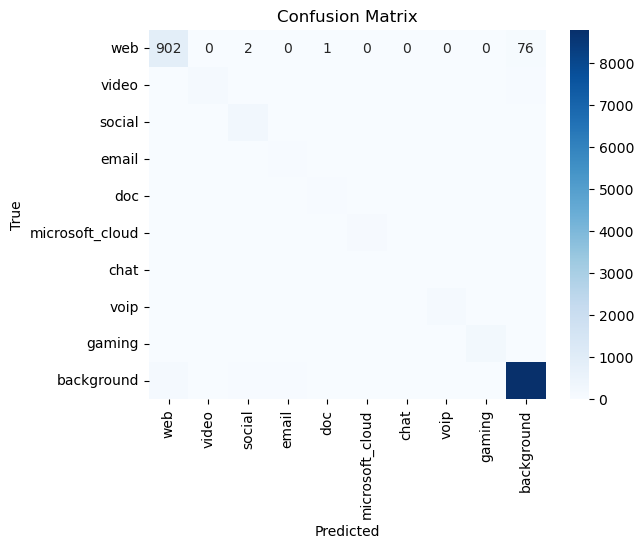

In [38]:

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize confusion matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['web','video','social','email','doc','microsoft_cloud','chat','voip','gaming','background'], yticklabels=['web','video','social','email','doc','microsoft_cloud','chat','voip','gaming','background'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.savefig('fs_net_gmm.png', dpi=300, bbox_inches='tight')
plt.show()

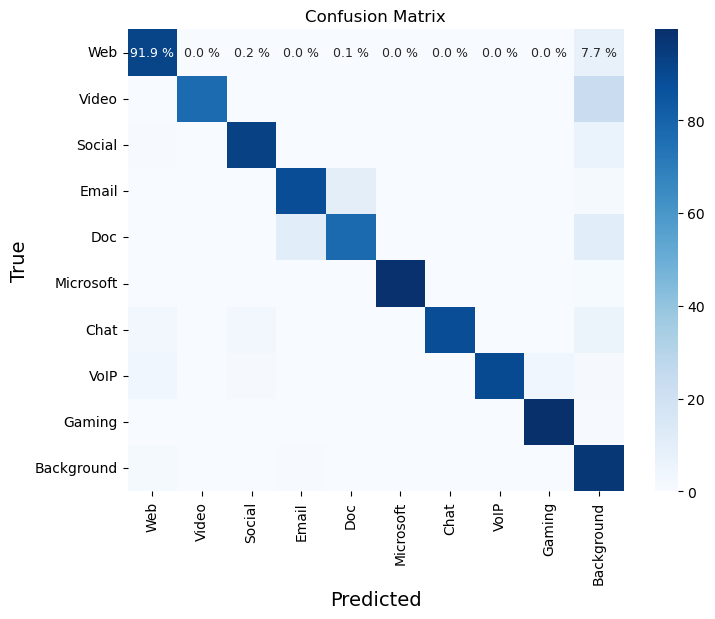

In [39]:
conf_matrix_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

class_names = ["Web","Video","Social","Email","Doc","Microsoft","Chat","VoIP","Gaming","Background"]

# Plot confusion matrix
plt.figure(figsize=(8, 6))
annot_kws = {"size": 9}
# sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
ax = sns.heatmap(conf_matrix_percentage, annot=True, fmt='.1f', cmap='Blues', xticklabels=class_names, yticklabels=class_names,annot_kws=annot_kws)
for t in ax.texts: t.set_text(t.get_text() + " %")
plt.xlabel('Predicted', fontsize=14)  
plt.ylabel('True', fontsize=14)
plt.title('Confusion Matrix')
plt.show()

In [40]:
y_pred = np.array(y_pred)
y_test = np.array(y_test)

In [41]:
per_class_acc = {}
for cls in np.unique(y_test):
    # find all positions where the true label is cls
    idx = np.where(y_test == cls)[0]
    # fraction of those that were correctly predicted
    per_class_acc[cls] = np.mean(y_pred[idx] == y_test[idx]) * 100

# print results
for cls, acc in per_class_acc.items():
    print(f"Label {cls}: {acc:.2f}% correct")

Label 0: 91.95% correct
Label 1: 76.88% correct
Label 2: 92.62% correct
Label 3: 88.33% correct
Label 4: 77.46% correct
Label 5: 99.12% correct
Label 6: 88.57% correct
Label 7: 89.68% correct
Label 8: 99.54% correct
Label 9: 96.55% correct


In [42]:
total = len(y_test)

for cls in np.unique(y_test):
    idx       = np.where(y_test == cls)[0]
    count_i   = len(idx)
    correct_i = np.sum(y_pred[idx] == cls)
    acc_i     = 100 * correct_i / count_i
    print(f"Label {cls}: {count_i}/{total} flows,  {correct_i}/{count_i} correct  ({acc_i:.2f}%)")

print(f"\nOverall: {np.sum(y_pred == y_test)}/{total} correct  ({100*np.mean(y_pred==y_test):.2f}%)")

Label 0: 981/11264 flows,  902/981 correct  (91.95%)
Label 1: 199/11264 flows,  153/199 correct  (76.88%)
Label 2: 325/11264 flows,  301/325 correct  (92.62%)
Label 3: 60/11264 flows,  53/60 correct  (88.33%)
Label 4: 71/11264 flows,  55/71 correct  (77.46%)
Label 5: 113/11264 flows,  112/113 correct  (99.12%)
Label 6: 35/11264 flows,  31/35 correct  (88.57%)
Label 7: 155/11264 flows,  139/155 correct  (89.68%)
Label 8: 219/11264 flows,  218/219 correct  (99.54%)
Label 9: 9106/11264 flows,  8792/9106 correct  (96.55%)

Overall: 10756/11264 correct  (95.49%)


In [43]:
percentile_per_cluster = {}
for k in range(gmm10.n_components):
    idxs = np.where(labels_train == k)[0]
    if len(idxs) == 0 or cluster_label_map.get(k) is None:
        percentile_per_cluster[k] = None
    else:
        p = 5
        percentile_per_cluster[k] = np.percentile(log_likes[idxs], p)

In [44]:
log_likes_test = gmm10.score_samples(test_features)  # shape (n_test,)
labels_test = gmm10.predict(test_features)

In [45]:
y_test=np.array(y_test)

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, accuracy_score


In [47]:
thresholds = [
    0.0,  0.5,  1.0,  1.5,  2.0,
    2.5,  3.0,  3.5,  4.0,  4.5,
    5.0,  5.5,  6.0,  6.5,  7.0,
    7.5,  8.0,  8.5,  9.0,  9.5,
    10.0
]
default_class      = 10
non9_true          = (y_test != 9)
total              = len(y_test)
total_non9         = non9_true.sum()
results            = []

# --- step 0: compute joint log‑likes and assigned labels
log_likes_train = gmm10.score_samples(all_features)   # shape (N_train,)
log_likes_test  = gmm10.score_samples(test_features)  # shape (N_test,)

# --- step 1: precompute global percentiles for each t>0
global_cutoffs = {
    t: np.percentile(log_likes_train, t)
    for t in thresholds if t != 0
}

for t in thresholds:
    if t == 0:
        # no filtering → everybody gets its cluster label
        y_pred2 = np.array([cluster_label_map[k] for k in labels_test])
    else:
        cutoff = global_cutoffs[t]
        # special case for true‑9 if you still need it:
        #   if the true label is 9, use the fixed 25% cutoff instead
        #   (comment out this block if you don't need it)
        y_pred2 = []
        for i, k in enumerate(labels_test):
            ll = log_likes_test[i]
            thresh = cutoff
            y_pred2.append(cluster_label_map[k] if ll >= thresh else default_class)
        y_pred2 = np.array(y_pred2)

    # then compute your keep_mask, metrics, coverage exactly as before…
    keep_mask   = (y_pred2 != default_class)
    y_true_kept = y_test[keep_mask]
    y_pred_kept = y_pred2[keep_mask]

    if keep_mask.sum() == 0:
        macro = weighted = acc_ = np.nan
    else:
        macro    = f1_score(y_true_kept, y_pred_kept, average='macro')
        weighted = f1_score(y_true_kept, y_pred_kept, average='weighted')
        acc_     = accuracy_score(y_true_kept, y_pred_kept)

    correct_mask = (y_pred2 == y_test)
    cov_all      = correct_mask.sum() / total
    cov_rel      = (correct_mask & non9_true).sum() / total_non9

    results.append({
        'Threshold':             t,
        'Macro F1':              round(macro,    2),
        'Weighted F1':           round(weighted, 2),
        'Accuracy':              round(acc_,     2),
        'Coverage All':        round(cov_all,  2),
        'Coverage Relevant':   round(cov_rel,  2),
        'y_true_kept':         y_true_kept,
        'y_pred_kept':         y_pred_kept
    })

    Threshold  Macro F1  Weighted F1  Accuracy  Coverage All  \
0         0.0      0.86         0.96      0.95          0.95   
1         0.5      0.90         0.97      0.97          0.93   
2         1.0      0.91         0.97      0.97          0.92   
3         1.5      0.92         0.97      0.97          0.92   
4         2.0      0.92         0.97      0.97          0.91   
5         2.5      0.92         0.97      0.97          0.90   
6         3.0      0.92         0.97      0.97          0.90   
7         3.5      0.92         0.97      0.97          0.89   
8         4.0      0.92         0.97      0.97          0.88   
9         4.5      0.92         0.97      0.97          0.88   
10        5.0      0.92         0.98      0.97          0.87   
11        5.5      0.93         0.98      0.97          0.86   
12        6.0      0.93         0.98      0.97          0.85   
13        6.5      0.93         0.98      0.98          0.84   
14        7.0      0.93         0.98    

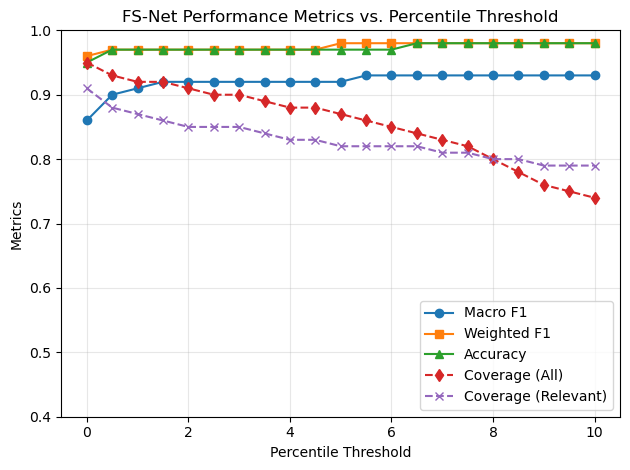

In [48]:
# assemble and display table
df = pd.DataFrame(results)
print(df)

# ——— plot all five metrics ———
plt.figure()
plt.plot(df['Threshold'], df['Macro F1'],             marker='o', label='Macro F1')
plt.plot(df['Threshold'], df['Weighted F1'],          marker='s', label='Weighted F1')
plt.plot(df['Threshold'], df['Accuracy'],             marker='^', label='Accuracy')
plt.plot(df['Threshold'], df['Coverage All'],       marker='d', linestyle='--', label='Coverage (All)')
plt.plot(df['Threshold'], df['Coverage Relevant'], marker='x', linestyle='--', label='Coverage (Relevant)')

plt.xlabel('Percentile Threshold')
plt.ylabel('Metrics')
plt.title('FS-Net Performance Metrics vs. Percentile Threshold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.ylim(0.40, 1.0)
plt.tight_layout()
plt.savefig('fsnet_gmm_full_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

In [49]:
entry = next(r for r in results if r['Threshold']==5.5)
y_true = entry['y_true_kept']
y_pred = entry['y_pred_kept']

In [50]:
macro_f1 = round(f1_score(y_true, y_pred, average='macro'), 2)
accuracy = round(accuracy_score(y_true, y_pred), 2)
average_f1 = round(f1_score(y_true, y_pred, average='weighted'), 2)
# Print or use the evaluation metrics as needed
# print(f'Weighted Average Accuracy: {weighted_accuracy}')
print(f'Macro Average F1 Score: {macro_f1}')
print(f'Accuracy: {accuracy}')
print(f'Weighted Average F1 Score: {average_f1}')

Macro Average F1 Score: 0.93
Accuracy: 0.97
Weighted Average F1 Score: 0.98


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

conf_matrix = confusion_matrix(y_true, y_pred)
conf_matrix_percentage = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100

class_names = ["Web","Video","Social","Email","Doc","Azure","Chat","VoIP","Gaming","Background"]
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names,annot_kws={"size": 14})
plt.xlabel('Predicted', fontsize=14)
plt.ylabel('True', fontsize=14)
plt.title('Confusion Matrix')
plt.savefig('gmm_fsnet_10classes.png', dpi=300, bbox_inches='tight')
plt.show()

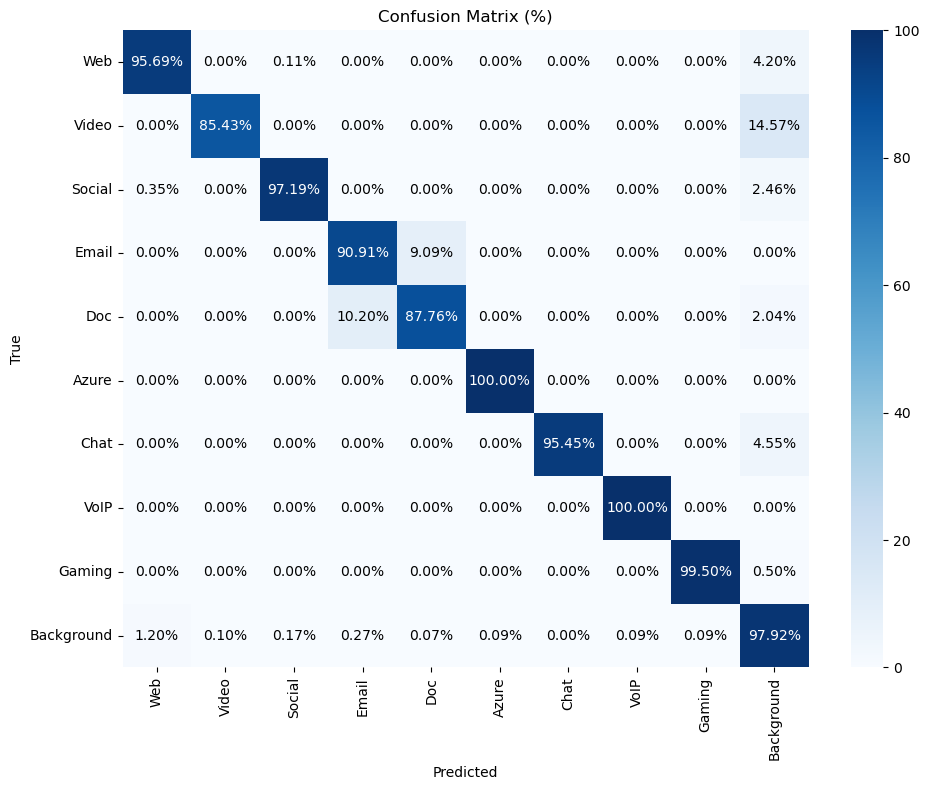

In [70]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

class_names = ["Web","Video","Social","Email","Doc","Azure","Chat","VoIP","Gaming","Background"]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm_pct,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=True,
    annot=False,
    ax=ax
)

threshold = cm_pct.max() / 2.0

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = "white" if cm_pct[i, j] > threshold else "black"
        ax.text(
            j + 0.5,
            i + 0.5,
            f"{cm_pct[i, j]:.2f}%",
            ha="center",
            va="center",
            color=color
        )

ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix (%)")
plt.tight_layout()

plt.savefig("confusion_matrix_percent.png", dpi=300, bbox_inches="tight")
plt.show()